In [1]:
import pandas as pd
import numpy as np
from keras.layers import Input, Dense, Dropout, BatchNormalization, LeakyReLU
from keras.models import Model
from keras.optimizers import Adam
import torch
from torch.utils.data import DataLoader, Dataset
import torch.nn as nn
import torch.optim as optim
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import os


2025-03-27 10:40:07.526450: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-03-27 10:40:09.248601: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-03-27 10:40:09.614348: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-03-27 10:40:09.858786: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-03-27 10:40:10.820110: I tensorflow/core/platform/cpu_feature_guar

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [62]:
# read training data(E4.5 natural blastocyst)
data = pd.read_csv('E450_expression.csv')

In [63]:
#The expression matrix is structured with cells as rows and genes as columns, comprising 2,000 highly variable genes in total
data

,Unnamed: 0,cell_type,Phlda2,Gjb2,Rhox6,Rhox9,Slc13a4,Maged1,Krt8,Col4a1,...,Fcgrt,Scpep1,Foxj1,Rassf1,Deptor,Atp5g2,Ptdss1,Dock4,Cpt1a,Tmem47
0,2_AAACGAATCCACACAA-1,Pre_EPI,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.000000,...,0.0,0.000000,0.0,0.000000,0.640243,2.538466,0.640243,0.640243,0.000000,0.000000
1,2_AAACGCTGTCGCCTAG-1,PaE,0.000000,0.0,0.824859,0.0,0.0,1.072384,0.000000,3.535743,...,0.0,0.000000,0.0,0.000000,0.000000,1.702100,2.233249,0.000000,0.495171,0.000000
2,2_AAACGCTGTGGCTGCT-1,Pre_EPI,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.000000,...,0.0,0.000000,0.0,0.000000,0.789791,1.948004,0.000000,0.000000,0.000000,0.789791
3,2_AAAGAACCATGACGAG-1,Pre_EPI,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.000000,...,0.0,0.765631,0.0,0.000000,0.765631,1.493141,0.000000,0.000000,0.000000,0.000000
4,2_AAAGTCCGTTGCTCCT-1,Pre_EPI,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.000000,...,0.0,0.818504,0.0,0.000000,0.000000,2.410259,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
850,2_TTTCCTCTCGGTTAGT-1,Pre_VE,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.842225,3.097587,...,0.0,1.292823,0.0,0.000000,0.000000,1.292823,0.000000,0.000000,0.000000,0.000000
851,2_TTTCGATCACGGCCAT-1,Pre_EPI,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.000000,...,0.0,0.759710,0.0,0.000000,1.186413,2.193171,0.000000,0.000000,0.000000,0.000000
852,2_TTTCGATTCATGGTAC-1,Pre_EPI,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.000000,...,0.0,0.570779,0.0,0.000000,0.570779,1.968113,0.000000,0.931885,0.000000,0.000000
853,2_TTTGATCGTATTTCCT-1,mTE,0.000000,0.0,0.000000,0.0,0.0,0.000000,3.002707,0.000000,...,0.0,0.000000,0.0,0.822419,0.000000,1.808943,0.000000,0.000000,0.822419,0.000000


In [66]:
#get expression data only
features = data.drop(['Unnamed: 0'], axis=1)
features = features.drop(['cell_type'], axis=1)
features

,Phlda2,Gjb2,Rhox6,Rhox9,Slc13a4,Maged1,Krt8,Col4a1,Itm2a,Serpine1,...,Fcgrt,Scpep1,Foxj1,Rassf1,Deptor,Atp5g2,Ptdss1,Dock4,Cpt1a,Tmem47
0,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.00000,...,0.0,0.000000,0.0,0.000000,0.640243,2.538466,0.640243,0.640243,0.000000,0.000000
1,0.000000,0.0,0.824859,0.0,0.0,1.072384,0.000000,3.535743,0.0,0.00000,...,0.0,0.000000,0.0,0.000000,0.000000,1.702100,2.233249,0.000000,0.495171,0.000000
2,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.00000,...,0.0,0.000000,0.0,0.000000,0.789791,1.948004,0.000000,0.000000,0.000000,0.789791
3,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.00000,...,0.0,0.765631,0.0,0.000000,0.765631,1.493141,0.000000,0.000000,0.000000,0.000000
4,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.0,1.26249,...,0.0,0.818504,0.0,0.000000,0.000000,2.410259,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
850,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.842225,3.097587,0.0,0.00000,...,0.0,1.292823,0.0,0.000000,0.000000,1.292823,0.000000,0.000000,0.000000,0.000000
851,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.00000,...,0.0,0.759710,0.0,0.000000,1.186413,2.193171,0.000000,0.000000,0.000000,0.000000
852,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.00000,...,0.0,0.570779,0.0,0.000000,0.570779,1.968113,0.000000,0.931885,0.000000,0.000000
853,0.000000,0.0,0.000000,0.0,0.0,0.000000,3.002707,0.000000,0.0,0.00000,...,0.0,0.000000,0.0,0.822419,0.000000,1.808943,0.000000,0.000000,0.822419,0.000000


In [67]:
# get cell type labels
labels = data[['cell_type']]
features = pd.DataFrame(features)
features = pd.DataFrame(features).astype('float32')

# One-hot encode cell_type
celltype_labels = pd.get_dummies(labels['cell_type'])

# Convert labels to tensor
labels_tensor = torch.tensor(celltype_labels.values, dtype=torch.float32)

# Define the dataset class
class GeneExpressionDataset(Dataset):
    def __init__(self, features, labels):
        if isinstance(features, pd.DataFrame):
            self.features = torch.tensor(features.values, dtype=torch.float32)
        else:
            raise TypeError("Features should be a DataFrame")

        if isinstance(labels, pd.DataFrame):
            self.labels = torch.tensor(labels.values, dtype=torch.float32)
        else:
            raise TypeError("Labels should be a DataFrame")
    
    def __len__(self):
        return len(self.features)
    
    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx]

In [68]:
# check cell type labels
celltype_labels

,PaE,Pre_EPI,Pre_VE,mTE,pTE
0,0,1,0,0,0
1,1,0,0,0,0
2,0,1,0,0,0
3,0,1,0,0,0
4,0,1,0,0,0
...,...,...,...,...,...
850,0,0,1,0,0
851,0,1,0,0,0
852,0,1,0,0,0
853,0,0,0,1,0


In [69]:
# Create dataset and data loader
dataset = GeneExpressionDataset(features, celltype_labels)
dataloader = DataLoader(dataset, batch_size=128, shuffle=True)

In [65]:
features.shape

(855, 2000)

In [3]:
# Define the Generator model
class Generator(nn.Module):
    def __init__(self, latent_dim, output_dim, gen_layers, label_dim):
        super(Generator, self).__init__()
        layers = []
        input_dim = latent_dim + label_dim
        for layer in gen_layers:
            layers.append(nn.Linear(input_dim, layer))
            layers.append(nn.ReLU())
            input_dim = layer
        layers.append(nn.Linear(input_dim, output_dim))
        self.model = nn.Sequential(*layers)
        self.final_activation = nn.ReLU()  # 添加ReLU激活函数

    def forward(self, z, labels):
        x = torch.cat([z, labels], dim=1)
        x = self.model(x)
        x = self.final_activation(x)  # 确保输出非负
        return x

# Define the Critic model
class Critic(nn.Module):
    def __init__(self, input_dim, critic_layers, label_dim):
        super(Critic, self).__init__()
        layers = []
        input_dim += label_dim
        for layer in critic_layers:
            layers.append(nn.Linear(input_dim, layer))
            layers.append(nn.ReLU())
            input_dim = layer
        layers.append(nn.Linear(input_dim, 1)) # Output a single score
        self.model = nn.Sequential(*layers)

    def forward(self, x, labels):
        x = torch.cat([x, labels], dim=1)
        return self.model(x)


In [4]:
## Define the conditional single-cell GAN (cscGAN)
class cscGAN:
    def __init__(self, latent_dim, input_dim, label_dim, gen_layers, critic_layers):
        self.latent_dim = latent_dim
        self.input_dim = input_dim
        self.label_dim = label_dim

        self.generator = Generator(latent_dim, input_dim, gen_layers, label_dim).to(device)
        self.critic = Critic(input_dim, critic_layers, label_dim).to(device)

        self.gen_optimizer = optim.Adam(self.generator.parameters(), lr=0.0002, betas=(0.5, 0.9))
        self.critic_optimizer = optim.Adam(self.critic.parameters(), lr=0.0002, betas=(0.5, 0.9))
# Compute gradient penalty for WGAN-GP
    def compute_gradient_penalty(self, real_data, fake_data, labels):
        alpha = torch.rand(real_data.size(0), 1, device=device)
        alpha = alpha.expand(real_data.size(0), real_data.size(1))
        interpolates = (alpha * real_data + ((1 - alpha) * fake_data)).requires_grad_(True)
        critic_interpolates = self.critic(interpolates, labels)
        gradients = torch.autograd.grad(
            outputs=critic_interpolates,
            inputs=interpolates,
            grad_outputs=torch.ones(critic_interpolates.size(), device=device),
            create_graph=True,
            retain_graph=True,
            only_inputs=True
        )[0]
        gradients = gradients.view(gradients.size(0), -1)
        slopes = torch.sqrt(torch.sum(gradients ** 2, dim=1))
        gradient_penalty = torch.mean((slopes - 1) ** 2)
        return gradient_penalty
 # Train the cscGAN
    def train(self, dataloader, n_epochs):
        for epoch in range(n_epochs):
            for i, (real_data, labels) in enumerate(dataloader):
                real_data = real_data.to(device)
                labels = labels.to(device)

                # # Train the critic multiple times per generator update
                for _ in range(5):
                    self.critic_optimizer.zero_grad()
                    z = torch.randn(real_data.size(0), self.latent_dim).to(device)
                    fake_data = self.generator(z, labels).detach()
                    # Compute critic outputs
                    critic_real = self.critic(real_data, labels).mean()
                    critic_fake = self.critic(fake_data, labels).mean()
                    # Compute gradient penalty and critic loss
                    gradient_penalty = self.compute_gradient_penalty(real_data, fake_data, labels)
                    critic_loss = critic_fake - critic_real + 10 * gradient_penalty
                     # Backprop and update critic
                    critic_loss.backward()
                    self.critic_optimizer.step()

                # Train the generator
                self.gen_optimizer.zero_grad()
                z = torch.randn(real_data.size(0), self.latent_dim).to(device)
                fake_data = self.generator(z, labels)
                critic_fake = self.critic(fake_data, labels).mean()
                gen_loss = -critic_fake
                # Backprop and update generator
                gen_loss.backward()
                self.gen_optimizer.step()
            # Print training progress
            print(f'Epoch [{epoch+1}/{n_epochs}]  Critic loss: {critic_loss.item():.4f}, Generator loss: {gen_loss.item():.4f}')

In [5]:
# Hyperparameter settings
latent_dim = 100
input_dim = 2000 ##Number of genes
label_dim = 5  ## Number of cell types(labels)
n_epochs = 1000
# Initialize and train the model
gen_layers = [128, 256, 512, 1024]
critic_layers = [1024, 512, 256, 128]

In [16]:
gan = cscGAN(latent_dim, input_dim, label_dim, gen_layers, critic_layers)
gan.train(dataloader, n_epochs)

/groups/MZG/app/miniconda3/envs/R4.2/lib/python3.11/site-packages/torch/autograd/graph.py:768: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at ../aten/src/ATen/cuda/CublasHandlePool.cpp:135.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Epoch [1/1000]  Critic loss: -33.5925, Generator loss: -1.5016
Epoch [2/1000]  Critic loss: -25.4811, Generator loss: -5.0756
Epoch [3/1000]  Critic loss: -17.4909, Generator loss: -2.2943
Epoch [4/1000]  Critic loss: -14.1022, Generator loss: -1.3339
Epoch [5/1000]  Critic loss: -14.1797, Generator loss: 0.0286
Epoch [6/1000]  Critic loss: -14.1947, Generator loss: -0.8248
Epoch [7/1000]  Critic loss: -14.5829, Generator loss: -4.2422
Epoch [8/1000]  Critic loss: -14.0514, Generator loss: 1.1932
Epoch [9/1000]  Critic loss: -15.3047, Generator loss: 0.0240
Epoch [10/1000]  Critic loss: -15.4283, Generator loss: -0.8176
Epoch [11/1000]  Critic loss: -15.9871, Generator loss: 3.0278
Epoch [12/1000]  Critic loss: -15.3990, Generator loss: -0.9773
Epoch [13/1000]  Critic loss: -16.3503, Generator loss: 1.3285
Epoch [14/1000]  Critic loss: -15.5738, Generator loss: -1.6259
Epoch [15/1000]  Critic loss: -15.8120, Generator loss: 1.0545
Epoch [16/1000]  Critic loss: -16.1162, Generator loss:

In [129]:
print(label_dim)

5


In [70]:
#generate data
# Ensure the generator is in evaluation mode
gan.generator.eval()

# Define a function to generate synthetic gene expression data
def generate_data(generator, num_samples, latent_dim, labels_df, device):
    with torch.no_grad():  
        noise = torch.randn(num_samples, latent_dim, device=device)
        sampled_labels_df = labels_df.sample(num_samples)
        sampled_labels_tensor = torch.tensor(sampled_labels_df.values, dtype=torch.float32).to(device)      
        generated_data = generator(noise, sampled_labels_tensor).cpu().numpy()  
    return generated_data, sampled_labels_df

#generate data
num_samples = 500
generated_data, sampled_labels_df = generate_data(gan.generator, num_samples, latent_dim, celltype_labels, device)


generated_df = pd.DataFrame(generated_data, columns=features.columns)

In [75]:
#save
generated_df.to_csv('generated_data.csv', index=False)

Text(0, 0.5, 't-SNE 2')

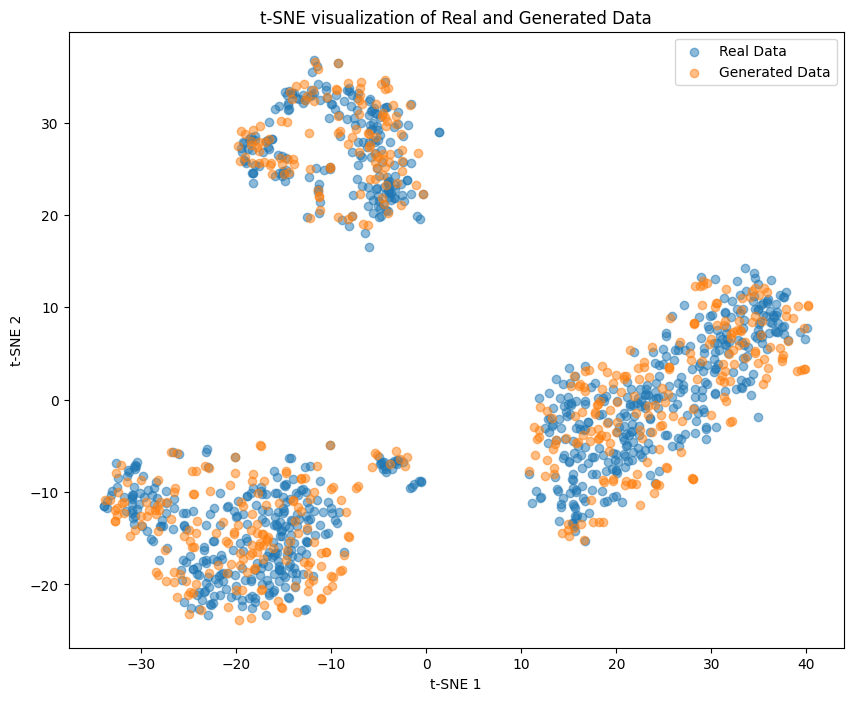

In [81]:
####Visualization
from sklearn.decomposition import PCA
# combine real data and generated data
combined_data = pd.concat([features, generated_df], axis=0)
labels = ['Real'] * len(features) + ['Generated'] * len(generated_df)
# PCA
pca = PCA(n_components=50) 
pca_result = pca.fit_transform(combined_data)
# t-SNE
tsne = TSNE(n_components=2, perplexity=40, n_iter=1000)
tsne_results = tsne.fit_transform(pca_result)

plt.figure(figsize=(10, 8))
plt.scatter(tsne_results[:len(features), 0], tsne_results[:len(features), 1], label='Real Data', alpha=0.5)
plt.scatter(tsne_results[len(features):, 0], tsne_results[len(features):, 1], label='Generated Data', alpha=0.5)
plt.legend()
plt.title('t-SNE visualization of Real and Generated Data')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
#plt.savefig('/central/groups/MZG/Wenqi/Dong/sccGAN/epoch_1000.pdf', format='pdf')

In [20]:
#save model
torch.save(gan.generator.state_dict(), 'generator.pth')
torch.save(gan.critic.state_dict(), 'critic.pth')

In [6]:
gan = cscGAN(latent_dim, input_dim, label_dim, gen_layers, critic_layers)
#load generatro
gan.generator.load_state_dict(torch.load('generator.pth'))
#load critic
gan.critic.load_state_dict(torch.load('critic.pth'))

/tmp/ipykernel_652354/746521556.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  gan.generator.load_state_dict(torch.load('generator.pth'))
/tmp/ipykernel_652354/74652155

<All keys matched successfully>

In [58]:
###generate specifc cell type data
def generate_celltype_data(generator, num_samples, latent_dim, celltype, device):
    with torch.no_grad(): 
        noise = torch.randn(num_samples, latent_dim, device=device)
        labels = torch.zeros((num_samples, 5), dtype=torch.float32, device=device)  # we have 5 cell types
        
        celltype_dict = {
            'PaE': 0,
            'Pre_EPI': 1, 
            'Pre_VE': 2,      
            'mTE': 3,
            'pTE': 4  # the order should be the same as your training labels
        }
        

        label_index = celltype_dict.get(celltype, None)
        if label_index is not None:
            labels[:, label_index] = 1.0 
        
        generated_data = generator(noise, labels).cpu().numpy()
        
    return generated_data

In [83]:

celltype = 'Pre_EPI'  # the cell type you want to generate
num_samples = 50  # number of cells
latent_dim = 100  
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu') 

generated_data = generate_celltype_data(gan.generator, num_samples, latent_dim, celltype, device)
generated_df = pd.DataFrame(generated_data, columns=features.columns)

In [87]:
#save
generated_df.to_csv('Generated_epi_data.csv', index=False)

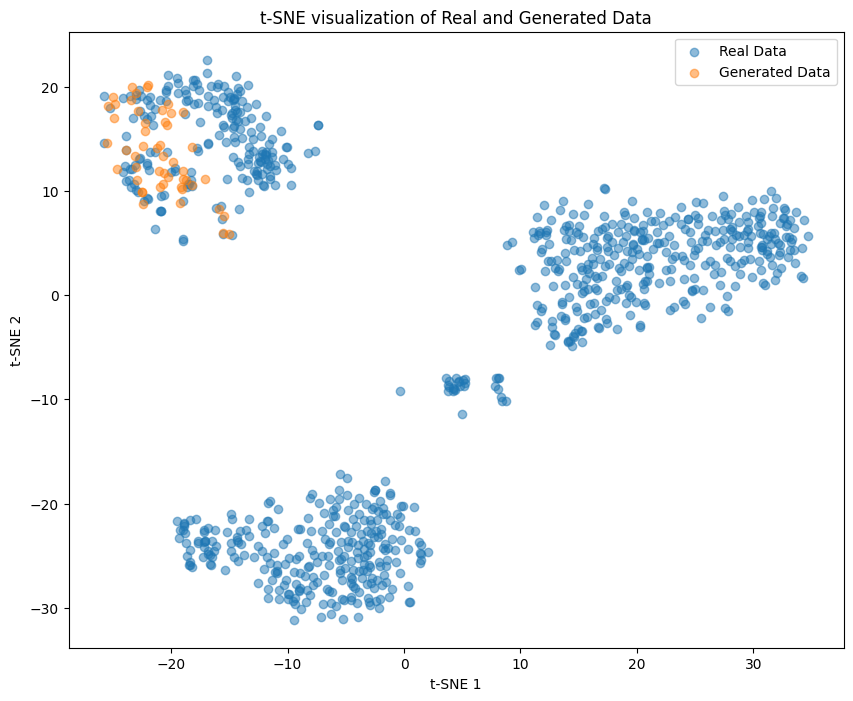

In [84]:
####Visualization
from sklearn.decomposition import PCA
combined_data = pd.concat([features, generated_df], axis=0)
labels = ['Real'] * len(features) + ['Generated'] * len(generated_df)

pca = PCA(n_components=50)  
pca_result = pca.fit_transform(combined_data)
tsne = TSNE(n_components=2, perplexity=40, n_iter=1000)
tsne_results = tsne.fit_transform(pca_result)

plt.figure(figsize=(10, 8))
plt.scatter(tsne_results[:len(features), 0], tsne_results[:len(features), 1], label='Real Data', alpha=0.5)
plt.scatter(tsne_results[len(features):, 0], tsne_results[len(features):, 1], label='Generated Data', alpha=0.5)
plt.legend()
plt.title('t-SNE visualization of Real and Generated Data')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.show()
#plt.savefig('/central/groups/MZG/Wenqi/Dong/sccGAN/Pre_EPI_generated.pdf', format='pdf')

In [86]:
#############Score of Blastoids #######################
# Since the GAN was trained in a label-conditioned manner (i.e., conditioned on cell type),
# scoring is more accurate when using real data from specific cell types as input.
# For example, to evaluate Rivron's blastoids, we use real TE and EPI cells separately
# to compute critic scores, which better reflects how well the GAN captures each lineage.
data = pd.read_csv('Rivron_EPI_expression.csv')

In [87]:
features = data.drop(['Unnamed: 0'], axis=1)
features = torch.tensor(features.values, dtype=torch.float32).to(device)

In [88]:
# Create 5 one-hot encoded labels
labels = torch.eye(5).to(device)  # Generate 5 labels, each as a one-hot vector

# Corresponding label names
label_names = ['PaE', 'Pre_EPI', 'Pre_VE', 'mTE', 'pTE']  # Label names corresponding to each index

# Compute critic scores for each label
scores = []
for i in range(5):
    label = labels[i].unsqueeze(0).expand(features.size(0), -1)  # Expand label to match batch size
    critic_score = gan.critic(features, label)  # Evaluate critic scores under this label
    avg_score = critic_score.mean().item()  # Calculate the average critic score
    scores.append(avg_score)

# Print the average score for each label
for i, score in enumerate(scores):
    print(f"Average critic score for label {label_names[i]}: {score:.4f}")
# Note:    
# If you are scoring using TE-like data (e.g., TE cells from blastoids),
# only the scores for 'mTE' and 'pTE' should be considered meaningful — ignore others.
# If you are scoring using EPI-like data, only the 'Pre_EPI' score is relevant.

标签 PaE 的平均评分: -1.6589
标签 Pre_EPI 的平均评分: -1.6772
标签 Pre_VE 的平均评分: -1.9631
标签 mTE 的平均评分: -0.3132
标签 pTE 的平均评分: -1.1070
